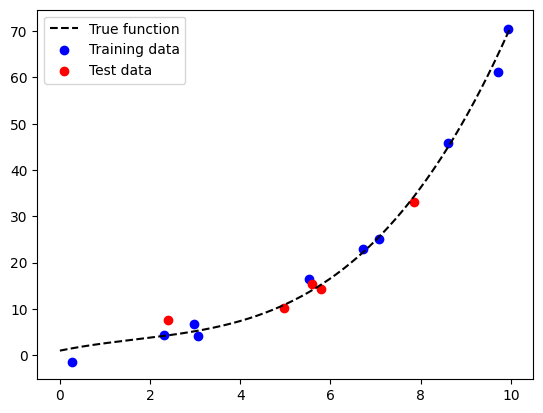

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Generate data
np.random.seed(0)
x_true = np.linspace(0, 10, 1000)
y_true = 1 + 2*x_true - 0.5*x_true**2 + 0.1*x_true**3

sample_size = 15
sampling_indices = np.random.choice(len(x_true), size=sample_size, replace=False)
x_sample = x_true[sampling_indices]
y_sample = y_true[sampling_indices] + np.random.normal(0, 2, size=sample_size)

num_train = 10
x_train = x_sample[:num_train]
y_train = y_sample[:num_train]

x_test = x_sample[num_train:]
y_test = y_sample[num_train:]

plt.figure()
plt.plot(x_true, y_true, label='True function', color='black', linestyle='--')
plt.scatter(x_train, y_train, label='Training data', color='blue')
plt.scatter(x_test, y_test, label='Test data', color='red')
plt.legend()
# Polynomial experiment
orders = np.arange(2, 151)
test_mse = []


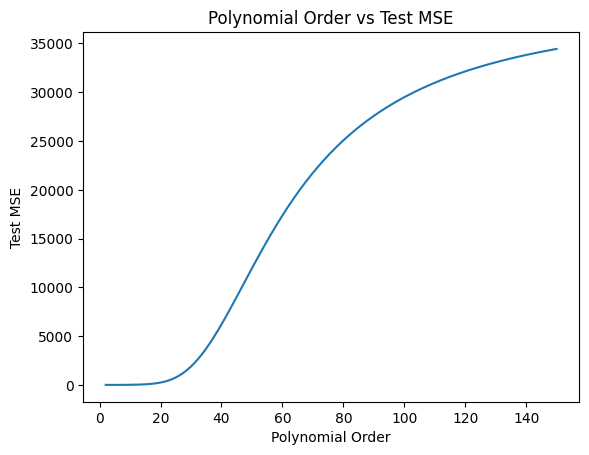

In [28]:
import warnings 
warnings.filterwarnings("ignore")
# Polynomial experiment
orders = np.arange(2, 151)
test_mse = []

for order in orders:
    coef = np.polyfit(x_train, y_train, order)
    y_pred = np.polyval(coef, x_test)
    mse = np.mean((y_pred - y_test)**2)
    test_mse.append(mse)

plt.figure()
plt.plot(orders, test_mse)
plt.xlabel("Polynomial Order")
plt.ylabel("Test MSE")
plt.title("Polynomial Order vs Test MSE")
plt.show()



In [31]:
from tqdm import tqdm
# Neural network experiment
def relu(z):
    return np.maximum(0, z)

def train_nn(hidden_size, epochs=10000, lr=1e-4):
    # Parameters
    W1 = np.random.randn(hidden_size, 1) * 0.1
    b1 = np.zeros((hidden_size, 1))
    W2 = np.random.randn(1, hidden_size) * 0.1
    b2 = np.zeros((1, 1))

    X = x_train.reshape(1, -1)
    Y = y_train.reshape(1, -1)

    for _ in tqdm(range(epochs)):
        Z1 = W1 @ X + b1
        A1 = relu(Z1)
        Y_pred = W2 @ A1 + b2

        dY = (Y_pred - Y)
        dW2 = dY @ A1.T / X.shape[1]
        db2 = np.mean(dY, axis=1, keepdims=True)
        dA1 = W2.T @ dY
        dZ1 = dA1 * (Z1 > 0)
        dW1 = dZ1 @ X.T / X.shape[1]
        db1 = np.mean(dZ1, axis=1, keepdims=True)

        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    # Evaluate on test set
    X_test = x_test.reshape(1, -1)
    Z1 = W1 @ X_test + b1
    A1 = relu(Z1)
    Y_pred_test = W2 @ A1 + b2
    mse = np.mean((Y_pred_test.flatten() - y_test)**2) + 0.01 * (np.sum(W1**2) + np.sum(W2**2))

    weights = {
        'W1': W1,
        'b1': b1,
        'W2': W2,
        'b2': b2
    }

    return mse, weights



100%|██████████| 10000/10000 [00:22<00:00, 446.59it/s]


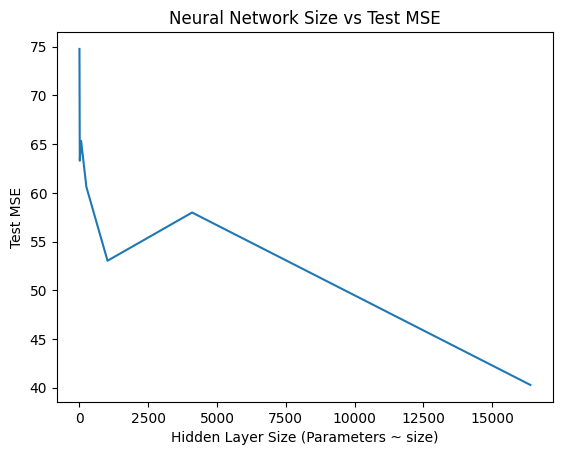

In [32]:
hidden_sizes = 2 ** np.arange(2, 16, 2)
nn_mse = []

weights_nn = {}
for h in hidden_sizes:
    mse, weights = train_nn(h)
    nn_mse.append(mse)
    weights_nn[h] = weights


plt.figure()
plt.plot(hidden_sizes, nn_mse)
plt.xlabel("Hidden Layer Size (Parameters ~ size)")
plt.ylabel("Test MSE")
plt.title("Neural Network Size vs Test MSE")
plt.show()


(-20.0, 80.0)

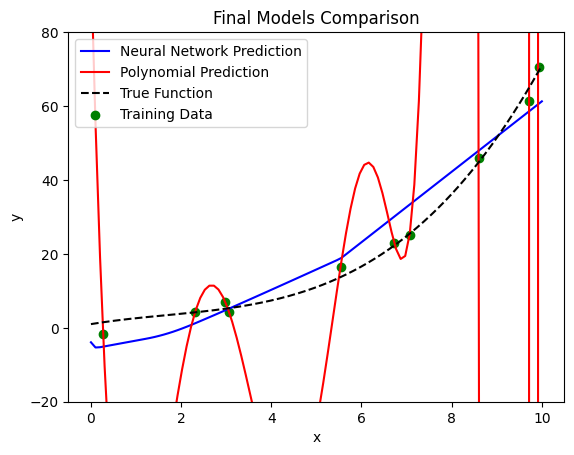

In [35]:
# plot the final trained neural network with the largest hidden size and the polynomial with the largest order
final_hidden_size = hidden_sizes[-1]
final_weights = weights_nn[final_hidden_size]
X_plot = np.linspace(0, 10, 100).reshape(1, -1)
Z1 = final_weights['W1'] @ X_plot + final_weights['b1']
A1 = relu(Z1)
Y_plot_nn = final_weights['W2'] @ A1 + final_weights['b2']
final_order = orders[-1]
coef_final = np.polyfit(x_train, y_train, final_order)
Y_plot_poly = np.polyval(coef_final, X_plot.flatten())
plt.figure()
plt.plot(X_plot.flatten(), Y_plot_nn.flatten(), label='Neural Network Prediction', color='blue')
plt.plot(X_plot.flatten(), Y_plot_poly, label='Polynomial Prediction', color='red')
plt.plot(x_true, y_true, label='True Function', color='black', linestyle='--')
plt.scatter(x_train, y_train, label='Training Data', color='green')
plt.xlabel("x")
plt.ylabel("y")
plt.title("Final Models Comparison")
plt.legend()
plt.ylim(-20, 80)


## Mysterious? No, so! 

### Deep Learning is Not So Mysterious or Different

https://arxiv.org/abs/2503.02113